<a href="https://colab.research.google.com/github/KeithRajbhandari/KRB-HTML/blob/main/Week_4_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
import pandas as pd

# This will prompt you to select a file from your computer
uploaded = files.upload()

# Read the uploaded file
df = pd.read_csv('advertising.csv')

Saving advertising.csv to advertising (1).csv


--- Dataset Overview ---
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9 

--- Data Cleaning ---
Missing values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Number of duplicate rows: 0

--- Exploratory Data Analysis ---
Summary Statistics:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


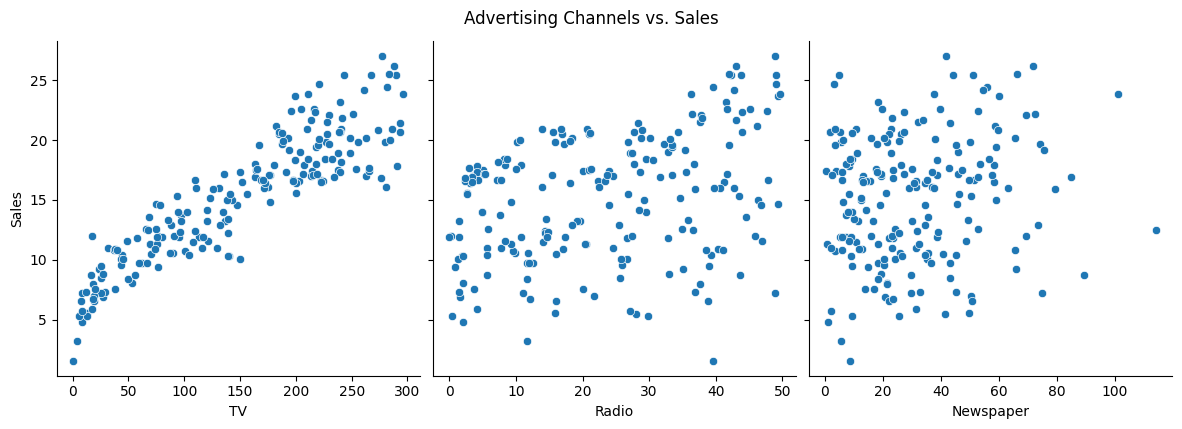

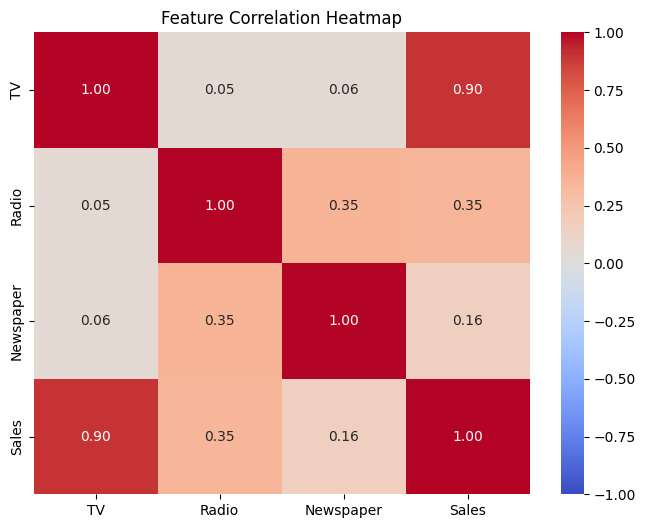


--- Regression Analysis ---
Model Coefficients:
           Coefficient
TV            0.054509
Radio         0.100945
Newspaper     0.004337
Intercept: 4.7141

Model Evaluation Metrics:
Mean Squared Error (MSE): 2.9078
Root Mean Squared Error (RMSE): 1.7052
Mean Absolute Error (MAE): 1.2748
R-squared (R2 Score): 0.9059



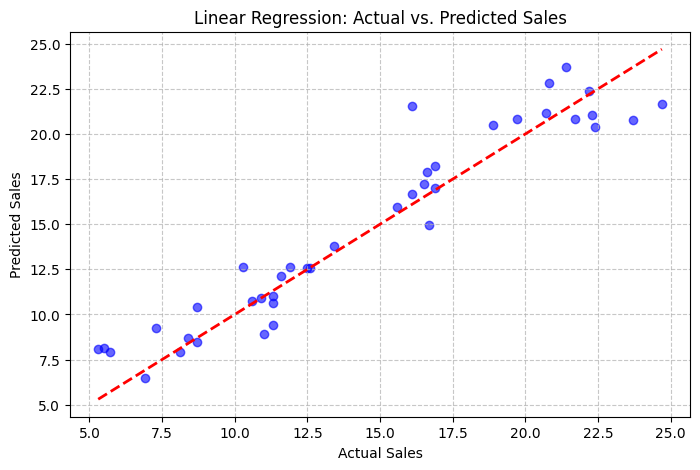

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load the Dataset
# Using 'advertising_2.csv' to ensure the cleaned dataset is referenced
file_name = "advertising.csv"
df = pd.read_csv(file_name)

print("--- Dataset Overview ---")
print(df.head(), "\n")

# 2. Data Cleaning
print("--- Data Cleaning ---")
print("Missing values:\n", df.isnull().sum())
print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Drop duplicates and any rows with missing values
df = df.drop_duplicates()
df = df.dropna()

# 3. Exploratory Data Analysis (EDA)
print("\n--- Exploratory Data Analysis ---")
print("Summary Statistics:")
print(df.describe())

# Pairplot: Advertising Channels vs Sales
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='scatter')
plt.suptitle('Advertising Channels vs. Sales', y=1.05)
plt.show()

# Heatmap: Feature Correlation
plt.figure(figsize=(8, 6))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap')
plt.show()

# 4. Define Features (X) and Target (y)
print("\n--- Regression Analysis ---")
X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

# 5. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Initialize and Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# Display Model Coefficients (from Script 1) and Intercept (from Script 2)
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("Model Coefficients:")
print(coefficients)
print(f"Intercept: {model.intercept_:.4f}\n")

# 7. Make Predictions
y_pred = model.predict(X_test)

# 8. Evaluate the Model
# Combining RMSE and MAE from Script 1 with MSE and R2 from both scripts
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Metrics:")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R-squared (R2 Score): {r2:.4f}\n")

# 9. Visualization: Actual vs. Predicted (From Script 1)
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)

# Plot a reference line (perfect prediction line)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.title('Linear Regression: Actual vs. Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()